# DSA stop-and-stare (steering-and-shift): TOD simulation + map-making

This notebook mirrors the end-to-end pipeline for the DSA stop-and-stare strategy:

- **9 fixed pointings** on a 3×3 hex grid centred on (RA = 180°, Dec = 52°), 21 min each.
- Each pointing **tracks a fixed (RA, Dec)**, so both azimuth and elevation drift smoothly during the integration; `elevation_deg` is passed to `TODSim.generate_TOD` as a per-sample array.
- Forward model via `limTOD.TODSim.generate_TOD`, inverse via `limTOD.HPW_mapmaking` (high-pass + Wiener filter).

**Scope.** Quick-look, single-file view of the pipeline. Production figures in
`README.md` come from `scripts/run_analysis_A.sh` + `scripts/produce_focus_maps.py` /
`scripts/produce_proposal_figures.py`. When the script caches exist on disk, this notebook
loads them and runs only the map-making; otherwise it regenerates each step.

Map-making recipe matches `scripts/compare_maps.run_mapmaking`: HP cutoff 30 mHz, order-4
Butterworth, beam-smoothed truth as prior mean with `σ = std(sky_truth)`, and explicit
per-sample noise variance `white_var × (op_i @ sky_truth)²`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import pickle
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from astropy.coordinates import EarthLocation
from astropy.time import Time, TimeDelta
import astropy.units as u

from limTOD import TODSim, GDSM_sky_model, HPW_mapmaking
from dsa_vis import (
    DSA_LAT, DSA_LON, DSA_HGT,
    radec_to_azel, dsa_beam_func, plot_map_compare,
)

In [2]:
dsa_location = EarthLocation(lat=DSA_LAT*u.deg,
                             lon=DSA_LON*u.deg,
                             height=DSA_HGT*u.m)

# TOD-simulation resolution — matches scripts/sim_steer_and_stare_tod.py.
sky_Nside = 64
beam_Nside = 64

# Map-making resolution. Default ns=64 matches scripts/run_analysis_A.sh
# so we reuse the existing `mapmaker_ops_steer_stare_ns64_baseline.pkl`
# operator cache. Set to 16 for a lighter (~3.7°/pixel) run that uses
# `mapmaker_ops_steer_stare_ns16_baseline.pkl` instead.
sky_Nside_map = 64

tod_sim = TODSim(
    ant_latitude_deg=DSA_LAT,
    ant_longitude_deg=DSA_LON,
    ant_height_m=DSA_HGT,
    beam_func=dsa_beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=beam_Nside,
    sky_nside=sky_Nside,
)

# Beam-edge truncation fraction. Re-used as the mapmaker's
# beam_truncate_frac_thres so forward and inverse agree on the beam support.
truncate_frac_thres = 1e-3
freq_list = [1000]  # MHz

In [3]:
# Define 3x3 hex pointing grid centered on (RA=180, Dec=52)
center_ra, center_dec = 180.0, 52.0
d_dec = 3.5
d_ra = 3.5 / np.cos(np.radians(center_dec))

pointings = []
for i_row, dec_offset in enumerate([-d_dec, 0, d_dec]):
    ra_shift = d_ra / 2 if i_row % 2 == 1 else 0
    for ra_offset in [-d_ra, 0, d_ra]:
        pointings.append((center_ra + ra_offset + ra_shift, center_dec + dec_offset))
pointings = np.array(pointings)

print(f"9-pointing hex grid centered on (RA={center_ra}, Dec={center_dec}):")
for i, (ra, dec) in enumerate(pointings):
    print(f"  PC {i}: ({ra:.2f}, {dec:.2f})")

9-pointing hex grid centered on (RA=180.0, Dec=52.0):
  PC 0: (174.32, 48.50)
  PC 1: (180.00, 48.50)
  PC 2: (185.68, 48.50)
  PC 3: (177.16, 52.00)
  PC 4: (182.84, 52.00)
  PC 5: (188.53, 52.00)
  PC 6: (174.32, 55.50)
  PC 7: (180.00, 55.50)
  PC 8: (185.68, 55.50)


In [4]:
# Cache name matches scripts/sim_steer_and_stare_tod.py --out-suffix _baseline,
# so if run_analysis_A.sh has already run the notebook just loads the cache.
TOD_CACHE = "simulated_TODs_steer_stare_baseline.npz"

try:
    data = np.load(TOD_CACHE, allow_pickle=True)
    freq_list = data["freq_list"].tolist()
    # Coerce to float64; the .npz stores arrays as dtype=object (Python
    # floats boxed in numpy), which later breaks scipy.linalg.solve.
    TOD_group = [np.asarray(t, dtype=np.float64) for t in data["TOD_group"]]
    LST_deg_list_group = [np.asarray(x, dtype=np.float64)
                          for x in data["LST_deg_list_group"]]
    azimuth_deg_list_group = [np.asarray(x, dtype=np.float64)
                              for x in data["azimuth_deg_list_group"]]
    elevation_deg_list_group = [np.asarray(x, dtype=np.float64)
                                for x in data["elevation_deg_list_group"]]
    print(f"Loaded {len(TOD_group)} cached TODs from {TOD_CACHE}")
except (FileNotFoundError, KeyError):
    base_start = "2024-04-15 04:00:00"
    t_per_pointing = 21 * 60  # 21 minutes in seconds
    dt = 2.0

    TOD_group = []
    LST_deg_list_group = []
    azimuth_deg_list_group = []
    elevation_deg_list_group = []

    print("Generating simulated TODs...")
    for i, (ra_i, dec_i) in enumerate(pointings):
        start_i = (Time(base_start)
                   + TimeDelta(i * t_per_pointing, format='sec')).iso
        time_list_i = np.arange(0, t_per_pointing, dt)

        az_i, el_i = radec_to_azel(ra_i, dec_i, time_list_i,
                                   start_i, dsa_location)
        print(f"  PC {i}: (RA={ra_i:.1f}, Dec={dec_i:.1f}), "
              f"el=[{el_i.min():.1f},{el_i.max():.1f}]")

        tod_array, _, _, LST_deg_list = tod_sim.generate_TOD(
            freq_list=freq_list,
            time_list=time_list_i,
            azimuth_deg_list=az_i,
            elevation_deg=el_i,  # per-sample array — tracking mode
            start_time_utc=start_i,
            return_LSTs=True,
            normalize_beam=False,
            truncate_frac_thres=truncate_frac_thres,
        )
        TOD_group.append(np.asarray(tod_array[0], dtype=np.float64))
        LST_deg_list_group.append(np.asarray(LST_deg_list, dtype=np.float64))
        azimuth_deg_list_group.append(np.asarray(az_i, dtype=np.float64))
        elevation_deg_list_group.append(np.asarray(el_i, dtype=np.float64))

    np.savez(TOD_CACHE,
             TOD_group=TOD_group,
             LST_deg_list_group=LST_deg_list_group,
             azimuth_deg_list_group=azimuth_deg_list_group,
             elevation_deg_list_group=elevation_deg_list_group,
             freq_list=freq_list)
    print(f"Done! Saved to {TOD_CACHE}")

Loaded 9 cached TODs from simulated_TODs_steer_stare_baseline.npz


In [5]:
# HPW mapmaker operator. The pickle cache matches the filename written
# by scripts/build_mapmaker_ops.py (suffix _baseline) — if the script
# has already run, load in seconds; otherwise rebuild.
OPS_CACHE = f"mapmaker_ops_steer_stare_ns{sky_Nside_map}_baseline.pkl"

try:
    with open(OPS_CACHE, "rb") as f:
        HPW_mapmaker = pickle.load(f)
    print(f"Loaded cached HPW_mapmaker operator from {OPS_CACHE}")
except (FileNotFoundError, EOFError):
    # Mapmaker beam resolution — matches scripts/build_mapmaker_ops.py's
    # --beam-nside-map 64 default.
    beam_Nside_map = 64
    beam_map = dsa_beam_func(freq=freq_list[0], nside=beam_Nside_map)
    HPW_mapmaker = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=LST_deg_list_group,
        lat_deg=DSA_LAT,
        azimuth_deg_list_group=azimuth_deg_list_group,
        elevation_deg_list_group=elevation_deg_list_group,
        threshold=0.05,
        nside_target=sky_Nside_map,
        beam_truncate_frac_thres=truncate_frac_thres,
    )
    with open(OPS_CACHE, "wb") as f:
        pickle.dump(HPW_mapmaker, f)
    print(f"Built HPW_mapmaker and cached to {OPS_CACHE}")

pixel_indices = HPW_mapmaker.pixel_indices
print(f"Pixel selection: {len(pixel_indices)} pixels at nside={sky_Nside_map}")

Loaded cached HPW_mapmaker operator from mapmaker_ops_steer_stare_ns64_baseline.pkl
Pixel selection: 376 pixels at nside=64


In [6]:
# Map-making recipe — mirrors scripts/compare_maps.run_mapmaking.
# See the azimuth-scan notebook for the full rationale; the recipe is
# deliberately identical across the two strategies so the only thing
# that differs is the scan pattern embedded in the operator.
DSA_BEAM_FWHM_DEG = 4.5
WHITE_VAR = 1e-7

sky_truth_full = GDSM_sky_model(freq=freq_list[0], nside=sky_Nside_map)
sky_truth = sky_truth_full[pixel_indices]

prior_mean_full = hp.smoothing(sky_truth_full,
                               fwhm=np.radians(DSA_BEAM_FWHM_DEG))
prior_mean = prior_mean_full[pixel_indices]

prior_sigma_K = max(float(np.std(sky_truth)), 1e-3)
prior_inv_cov = np.ones_like(sky_truth) / prior_sigma_K**2

nv_floor = WHITE_VAR * (1e-3 * float(np.mean(sky_truth)))**2
noise_variance = []
if HPW_mapmaker.num_tods > 1:
    for op_i in HPW_mapmaker.Tsys_operators:
        expected_tod = np.asarray(op_i) @ sky_truth
        noise_variance.append(WHITE_VAR * expected_tod**2 + nv_floor)
else:
    expected_tod = np.asarray(HPW_mapmaker.Tsys_operators) @ sky_truth
    noise_variance = [WHITE_VAR * expected_tod**2 + nv_floor]

cutoff_freq_group = np.array([3e-2] * len(TOD_group))

sky_map_est, sky_map_uncertainty = HPW_mapmaker(
    TOD_group=TOD_group,
    dtime=2.0,
    cutoff_freq_group=cutoff_freq_group,
    Tsky_prior_mean=prior_mean,
    Tsky_prior_inv_cov_diag=prior_inv_cov,
    noise_variance=noise_variance,
    regularization=1e-12,
    return_full_cov=False,
    filter_order=4,
)

print(f"sky_map_est:  min={sky_map_est.min():.3f} K, "
      f"max={sky_map_est.max():.3f} K, mean={sky_map_est.mean():.3f} K")
print(f"sky_truth:    min={sky_truth.min():.3f} K, "
      f"max={sky_truth.max():.3f} K, mean={sky_truth.mean():.3f} K")
print(f"Residual RMS: {np.std(sky_map_est - sky_truth)*1e3:.1f} mK")

sky_map_est:  min=4.588 K, max=4.839 K, mean=4.666 K
sky_truth:    min=4.533 K, max=4.875 K, mean=4.659 K
Residual RMS: 29.2 mK


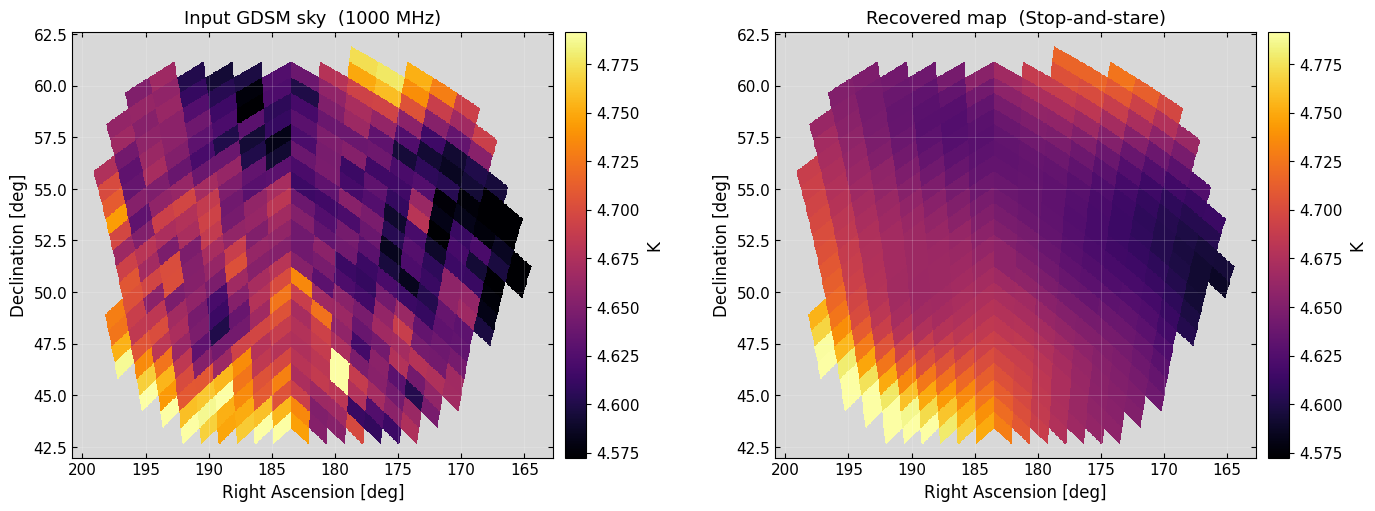

In [7]:
# Quick-look comparison. Save path is suffixed `_notebook` so it does
# not collide with the proposal/focus figures written by the scripts
# (`figures/compare_focus_steer_and_stare_baseline__autonoise_ns64_hp.png`).
fig = plot_map_compare(
    sky_est=sky_map_est,
    sky_truth=sky_truth,
    nside=sky_Nside_map,
    pixel_indices=pixel_indices,
    freq_mhz=freq_list[0],
    strategy_name="Stop-and-stare",
    savepath="figures/map_steer_and_stare_notebook.png",
)
plt.show()